# Principal Component Analysis on Ken French Return Panels

## Overview
This notebook applies **Principal Component Analysis (PCA)** to asset return panels from Ken French's Data Library.

The main goal is to extract latent return factors from the data and compare them to the **Fama–French factors**.

## What this notebook does
We analyze three panels:
1. International index returns
2. 100 portfolios sorted on Size and Book-to-Market
3. 49 industry portfolios

For each panel, we:
- clean the return matrix
- convert U.S. returns to **excess returns** by subtracting the risk-free rate
- standardize returns
- run PCA
- interpret scree plots, PC scores, and loadings
- compare extracted PCs with the Fama–French 3 factors

## Economic idea
PCA finds the linear combinations of assets that explain the most variation in returns.

In asset-pricing language, it is a statistical way to estimate latent factors and factor loadings directly from the data.

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn statsmodels requests

import io
import re
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## Data source and parsing

All data come from **Ken French’s Data Library**.

A practical issue is that these files are distributed as zipped text/CSV files with irregular headers and footers, so we need custom parsing functions.

Important conventions:
- returns are reported in **percent**
- we divide all returns by **100**
- for U.S. panels, we subtract the risk-free rate to obtain **excess returns**

In [2]:
def download_zip_text(url):
    response = requests.get(url)
    response.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(response.content))
    filename = z.namelist()[0]
    return z.read(filename).decode("utf-8", errors="ignore")

In [3]:
def parse_ff3_factors(text):
    """
    Parse the monthly Fama-French 3 factors file.
    Returns a DataFrame indexed by Timestamp.
    """
    lines = text.splitlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Mkt-RF" in line and "SMB" in line and "HML" in line and "RF" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("Could not find FF3 header row.")

    data_start = header_idx + 1
    data_end = None

    for i in range(data_start, len(lines)):
        line = lines[i].strip()
        if line == "" or "Annual Factors:" in line:
            data_end = i
            break

    if data_end is None:
        data_end = len(lines)

    csv_text = "\n".join(lines[header_idx:data_end])

    df = pd.read_csv(io.StringIO(csv_text))
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: "Date"})
    df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m")
    df = df.set_index("Date")

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df / 100.0

In [4]:
def parse_monthly_panel(text):
    """
    Parse a Ken French monthly panel file where the table starts with a row
    whose first entry is a date like YYYYMM.
    Returns a DataFrame indexed by Timestamp.
    """
    lines = text.splitlines()

    start_idx = None
    for i, line in enumerate(lines):
        if re.match(r"^\s*,?\s*\d{6}\s*,", line) or re.match(r"^\s*\d{6}\s*,", line):
            start_idx = i
            break

    if start_idx is None:
        raise ValueError("Could not find monthly data start.")

    # header is immediately above the first YYYYMM row
    header_idx = start_idx - 1

    end_idx = None
    for i in range(start_idx, len(lines)):
        line = lines[i].strip()
        if line == "" or "Annual" in line:
            end_idx = i
            break

    if end_idx is None:
        end_idx = len(lines)

    csv_text = "\n".join(lines[header_idx:end_idx])
    df = pd.read_csv(io.StringIO(csv_text))
    df.columns = [str(c).strip() for c in df.columns]

    first_col = df.columns[0]
    df = df.rename(columns={first_col: "Date"})
    df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m")
    df = df.set_index("Date")

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df / 100.0

In [5]:
def parse_international_indices(text):
    """
    Parse Ken French international indices monthly data.
    The file is whitespace-separated, not comma-separated.
    """
    lines = text.splitlines()

    # Find first monthly row like 197501 ...
    start_idx = None
    for i, line in enumerate(lines):
        if re.match(r"^\s*\d{6}\s+", line):
            start_idx = i
            break

    if start_idx is None:
        raise ValueError("Could not find monthly data start in international file.")

    # Find end of monthly block
    end_idx = None
    for i in range(start_idx, len(lines)):
        line = lines[i].strip()
        if line == "" or "Annual" in line or "Copyright" in line:
            end_idx = i
            break

    if end_idx is None:
        end_idx = len(lines)

    raw = "\n".join(lines[start_idx:end_idx])

    # Read whitespace-separated data
    df = pd.read_csv(io.StringIO(raw), sep=r"\s+", header=None)

    # Assign unique column names manually
    df.columns = [
        "Date",
        "Mkt",
        "BE_ME_High", "BE_ME_Low",
        "EP_High", "EP_Low",
        "CE_P_High", "CE_P_Low",
        "Yld_High", "Yld_Low",
        "Zero"
    ]

    # Parse dates
    df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m")
    df = df.set_index("Date")

    # Convert everything to numeric safely
    df = df.apply(lambda col: pd.to_numeric(col, errors="coerce"))

    # Ken French returns are in percent
    df = df / 100.0

    return df

## Load the datasets

We load:
- Fama–French 3 factors
- 100 Size × Book-to-Market portfolios
- 49 industry portfolios
- 10 international indices

These correspond directly to the three panels studied in the recitation.

In [6]:
ff3_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
bm100_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/100_Portfolios_10x10_CSV.zip"
ind49_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/49_Industry_Portfolios_CSV.zip"
intl10_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_International_Indices.zip"

In [7]:
ff3 = parse_ff3_factors(download_zip_text(ff3_url))
bm100 = parse_monthly_panel(download_zip_text(bm100_url))
ind49 = parse_monthly_panel(download_zip_text(ind49_url))
intl10 = parse_international_indices(download_zip_text(intl10_url))

In [8]:
intl_text = download_zip_text(intl10_url)
print("\n".join(intl_text.splitlines()[:40]))


     Value-Weight Dollar Returns      All 4 Data Items Not Reqd
                -- BE/ME --   --- E/P ---   --- CE/P --   ------  Yld  -----
          Mkt   High    Low   High    Low   High    Low   High    Low   Zero
197501  15.19  14.29  16.80  14.76  17.29  14.02  17.40  13.47  17.00  17.17
197502   8.49   9.24   9.23  10.44   7.84  11.86   7.27   7.51   7.75  12.49
197503  -0.59  -0.68  -0.12  -0.89   0.62  -1.02   0.80  -0.72   0.25   0.30
197504   3.81   2.53   3.63   1.77   3.67   1.41   3.74   2.46   4.77   3.63
197505  -3.74  -3.32  -2.27  -3.50  -2.66  -3.76  -2.26  -4.17  -2.83  -6.43
197506  -2.97  -4.47  -3.41  -4.63  -3.14  -4.94  -3.25  -3.81  -3.29  -4.61
197507  -3.55  -2.91  -3.42  -2.14  -3.47  -2.70  -2.51  -2.91  -3.29  -1.33
197508  -1.89  -1.84  -1.79  -1.81  -2.89  -2.15  -3.03  -1.32  -2.76  -0.48
197509  -6.23  -7.02  -6.33  -6.71  -6.98  -7.26  -6.82  -5.82  -6.98  -6.47
197510   9.34   9.59   8.39  11.07   9.53   9.15  11.63  10.02   9.18   7.57
197511   5.

In [9]:
print("FF3 columns:", ff3.columns.tolist())
print("100 portfolios shape:", bm100.shape)
print("49 industries shape:", ind49.shape)
print("International indices shape:", intl10.shape)

display(intl10.head())

FF3 columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
100 portfolios shape: (1196, 100)
49 industries shape: (1196, 49)
International indices shape: (612, 10)


,Mkt,BE_ME_High,BE_ME_Low,EP_High,EP_Low,CE_P_High,CE_P_Low,Yld_High,Yld_Low,Zero
Date,,,,,,,,,,
1975-01-01,0.1519,0.1429,0.1680,0.1476,0.1729,0.1402,0.1740,0.1347,0.1700,0.1717
1975-02-01,0.0849,0.0924,0.0923,0.1044,0.0784,0.1186,0.0727,0.0751,0.0775,0.1249
1975-03-01,-0.0059,-0.0068,-0.0012,-0.0089,0.0062,-0.0102,0.0080,-0.0072,0.0025,0.0030
1975-04-01,0.0381,0.0253,0.0363,0.0177,0.0367,0.0141,0.0374,0.0246,0.0477,0.0363
1975-05-01,-0.0374,-0.0332,-0.0227,-0.0350,-0.0266,-0.0376,-0.0226,-0.0417,-0.0283,-0.0643


## Cleaning the return panel

PCA requires a complete matrix.

So we:
- restrict to the desired date range
- subtract the risk-free rate when needed
- drop columns with poor coverage
- drop remaining rows with missing values

This is exactly the cleaning step used in the recitation.

In [10]:
def slice_by_date(df, start=None, end=None):
    out = df.copy()
    if start is not None:
        out = out.loc[out.index >= pd.Timestamp(start)]
    if end is not None:
        out = out.loc[out.index <= pd.Timestamp(end)]
    return out


def prepare_panel(returns, start=None, end=None, rf=None, min_col_coverage=0.99):
    df = slice_by_date(returns, start=start, end=end)

    if rf is not None:
        aligned = df.join(rf.to_frame("RF"), how="inner")
        df = aligned.drop(columns="RF").sub(aligned["RF"], axis=0)

    coverage = df.notna().mean()
    keep = coverage[coverage >= min_col_coverage].index
    dropped = coverage[coverage < min_col_coverage].index.tolist()

    df = df[keep].dropna(how="any")
    return df, dropped

In [11]:
intl_panel, intl_dropped = prepare_panel(
    intl10,
    start="1975-01-01",
    min_col_coverage=0.99
)

bm100_excess, bm100_dropped = prepare_panel(
    bm100,
    start="1975-01-01",
    rf=ff3["RF"],
    min_col_coverage=0.99
)

ind49_excess, ind49_dropped = prepare_panel(
    ind49,
    start="1975-01-01",
    rf=ff3["RF"],
    min_col_coverage=0.99
)

print("International panel:", intl_panel.shape, "Dropped:", intl_dropped)
print("100 Size-B/M excess panel:", bm100_excess.shape, "Dropped:", bm100_dropped)
print("49 industry excess panel:", ind49_excess.shape, "Dropped:", ind49_dropped)

International panel: (612, 10) Dropped: []
100 Size-B/M excess panel: (614, 100) Dropped: []
49 industry excess panel: (614, 49) Dropped: []


## PCA setup

The main methodological choice is whether to run:
- **correlation PCA**: standardize each asset return series
- **covariance PCA**: only demean

In the recitation, the default choice is **correlation PCA**, implemented with `StandardScaler`, so that all assets are placed on the same scale.

In [12]:
def run_pca(panel, n_components=5, standardize=True):
    X = panel.copy()

    if standardize:
        scaler = StandardScaler(with_mean=True, with_std=True)
        Z = scaler.fit_transform(X.values)
    else:
        Z = X.values - X.values.mean(axis=0)

    pca = PCA(n_components=n_components)
    scores_array = pca.fit_transform(Z)
    loadings_array = pca.components_.T

    scores = pd.DataFrame(
        scores_array,
        index=X.index,
        columns=[f"PC{i}" for i in range(1, n_components + 1)]
    )

    loadings = pd.DataFrame(
        loadings_array,
        index=X.columns,
        columns=[f"PC{i}" for i in range(1, n_components + 1)]
    )

    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=[f"PC{i}" for i in range(1, n_components + 1)],
        name="ExplainedVarianceRatio"
    )

    eigenvalues = pd.Series(
        pca.explained_variance_,
        index=[f"PC{i}" for i in range(1, n_components + 1)],
        name="Eigenvalue"
    )

    # Orient PC1 so it correlates positively with the cross-sectional average return
    reference = panel.mean(axis=1)
    if scores["PC1"].corr(reference) < 0:
        scores["PC1"] *= -1
        loadings["PC1"] *= -1

    return {
        "scores": scores,
        "loadings": loadings,
        "explained": explained,
        "eigenvalues": eigenvalues,
        "pca_model": pca
    }

In [13]:
intl_res = run_pca(intl_panel, n_components=5, standardize=True)
bm100_res = run_pca(bm100_excess, n_components=5, standardize=True)
ind49_res = run_pca(ind49_excess, n_components=5, standardize=True)

bm100_res["explained"]

,ExplainedVarianceRatio
PC1,0.709974
PC2,0.052684
PC3,0.032187
PC4,0.018762
PC5,0.011969


## Scree plots

The scree plot helps answer:
- how dominant the first factor is
- whether there is a sharp elbow after the first few PCs
- how many components are needed to explain a large fraction of total variation

In [14]:
def plot_scree(result, title):
    explained = result["explained"].values
    pcs = np.arange(1, len(explained) + 1)
    cumulative = np.cumsum(explained)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(pcs, explained * 100)
    axes[0].set_title(f"{title}: Scree Plot")
    axes[0].set_xlabel("Principal Component")
    axes[0].set_ylabel("% Variance Explained")
    axes[0].set_xticks(pcs)

    axes[1].plot(pcs, cumulative * 100, marker="o")
    axes[1].axhline(90, linestyle="--", label="90%")
    axes[1].set_title(f"{title}: Cumulative Variance")
    axes[1].set_xlabel("Number of Components")
    axes[1].set_ylabel("Cumulative % Explained")
    axes[1].set_xticks(pcs)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

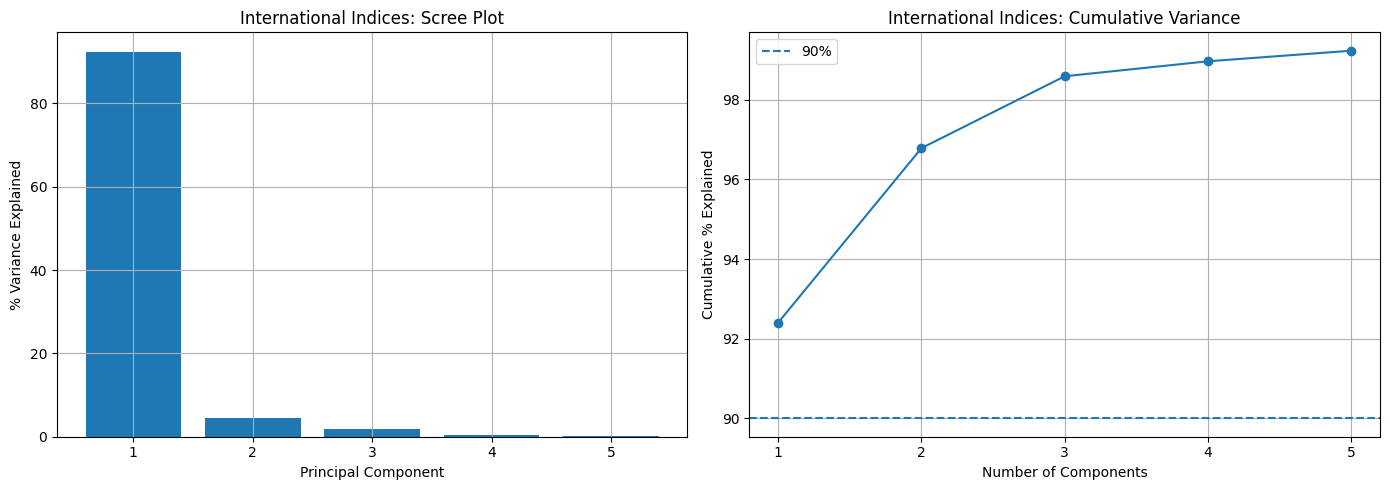

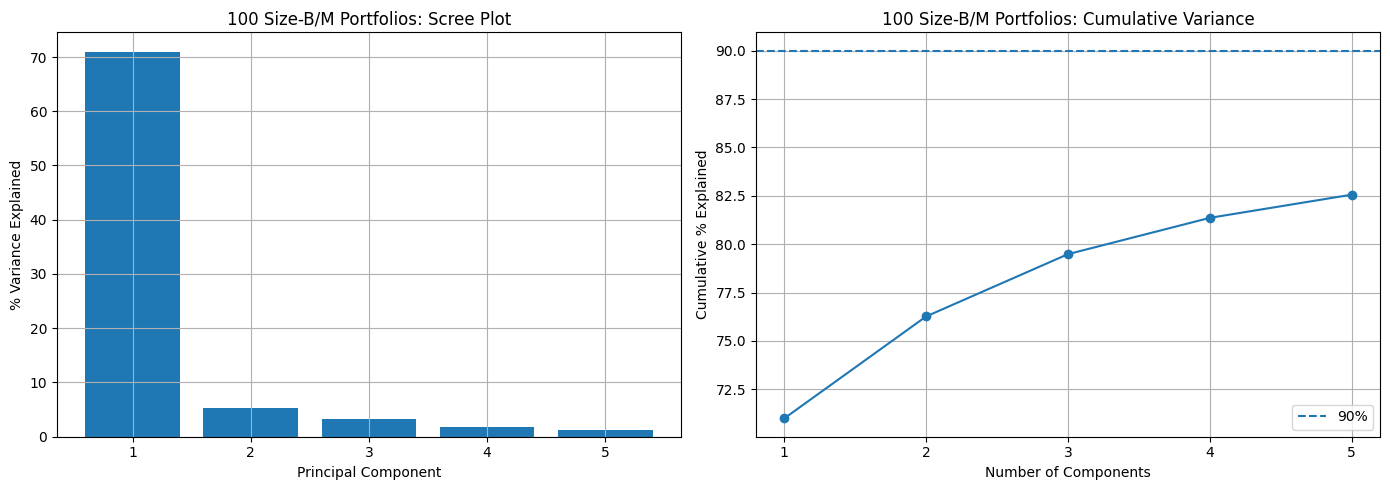

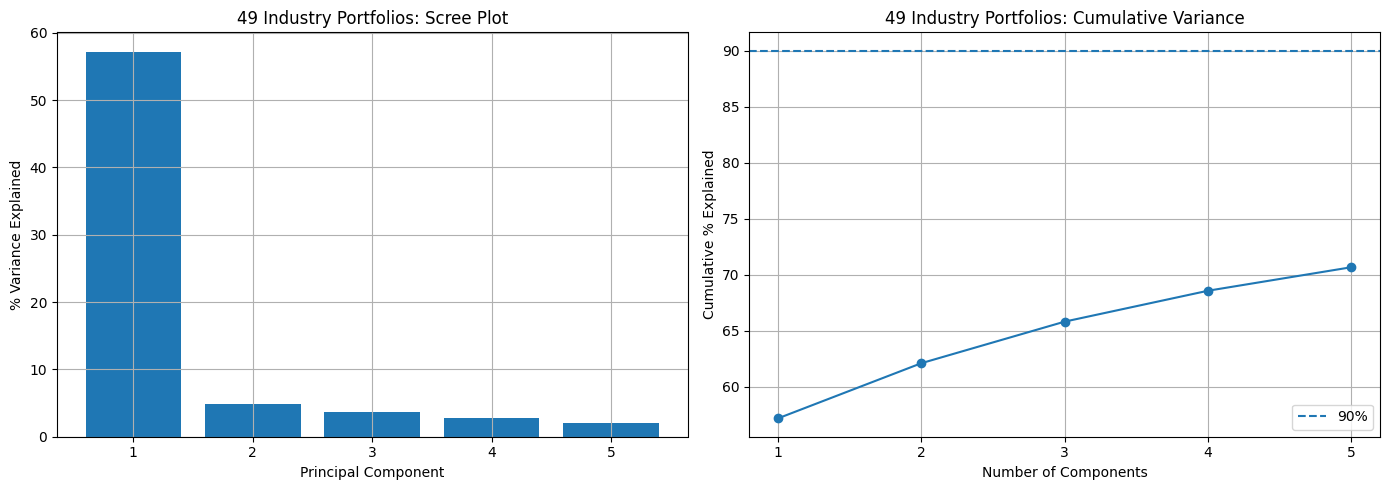

In [15]:
plot_scree(intl_res, "International Indices")
plot_scree(bm100_res, "100 Size-B/M Portfolios")
plot_scree(ind49_res, "49 Industry Portfolios")

### Interpretation

The three panels have very different factor structures.

- The **international index panel** is the simplest case: one broad market factor explains almost everything.
- The **100 Size-B/M panel** is still market-dominated, but there is enough cross-sectional structure to reveal additional factors.
- The **49 industry panel** is more heterogeneous, so the market factor explains much less and more PCs are needed.

This shows an important economic point:
the factors PCA extracts depend on **how the cross-section is sliced**.

In [16]:
def plot_pc_scores(result, title, n_show=3):
    scores = result["scores"]

    fig, axes = plt.subplots(n_show, 1, figsize=(12, 3 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]

    for i in range(n_show):
        pc = f"PC{i+1}"
        axes[i].plot(scores.index, scores[pc], linewidth=0.8)
        axes[i].set_title(f"{title}: {pc} score over time")
        axes[i].set_ylabel(pc)

    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

In [17]:
def plot_pc_scores(result, title, n_show=3):
    scores = result["scores"]

    fig, axes = plt.subplots(n_show, 1, figsize=(12, 3 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]

    for i in range(n_show):
        pc = f"PC{i+1}"
        axes[i].plot(scores.index, scores[pc], linewidth=0.8)
        axes[i].set_title(f"{title}: {pc} score over time")
        axes[i].set_ylabel(pc)

    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

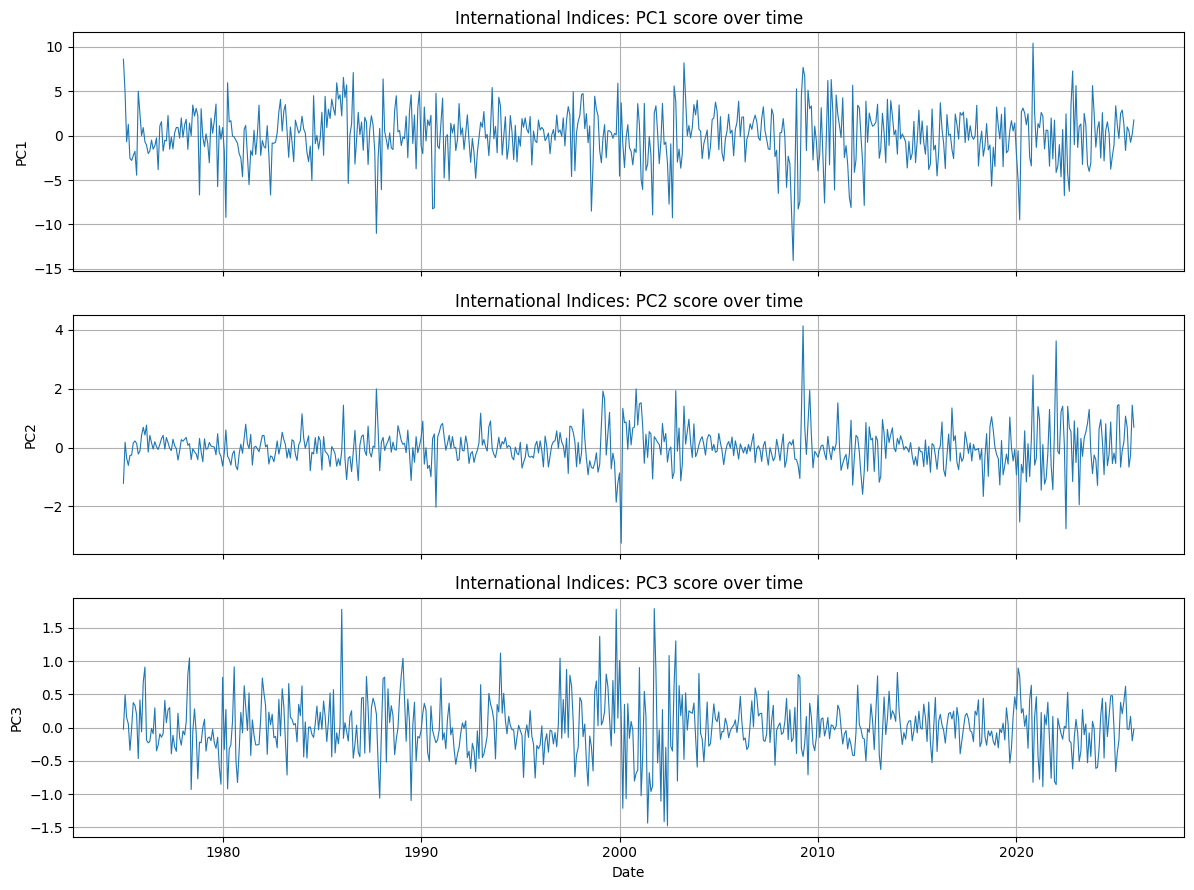

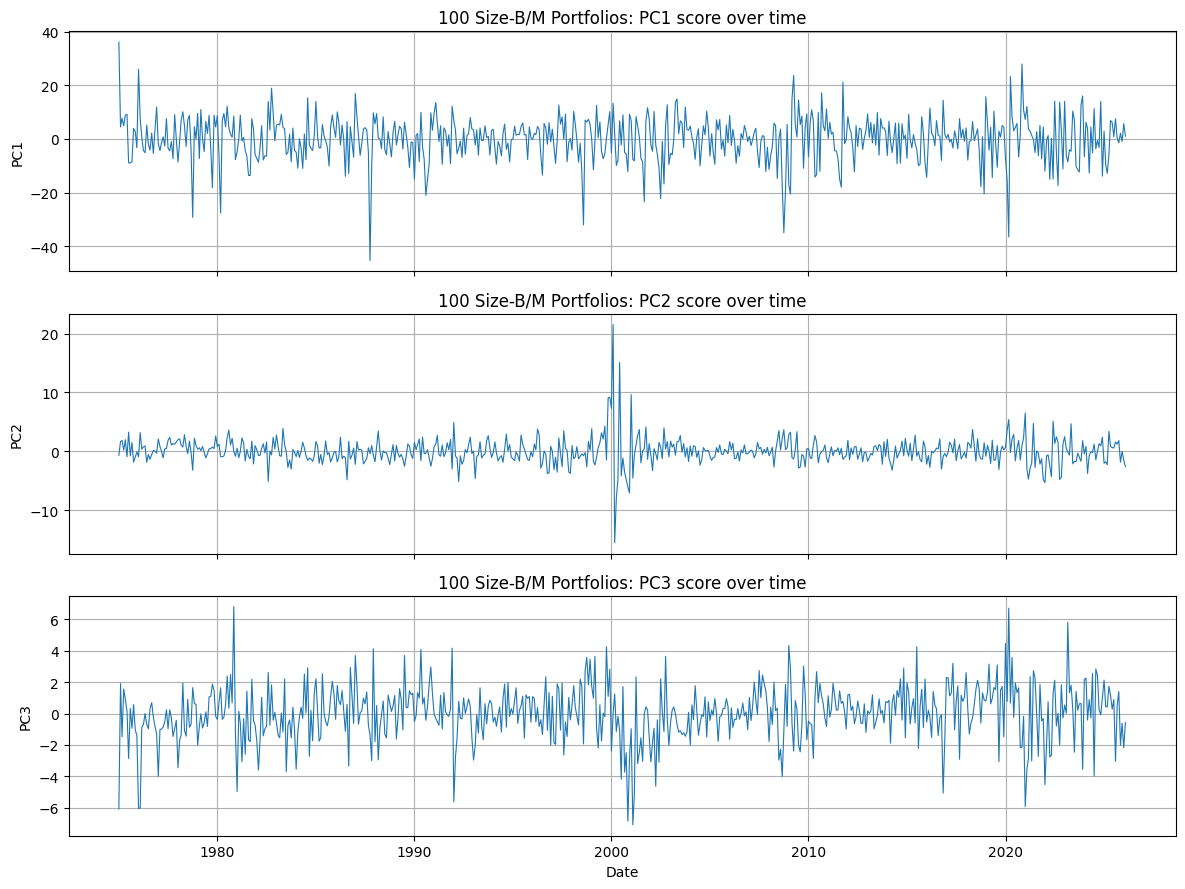

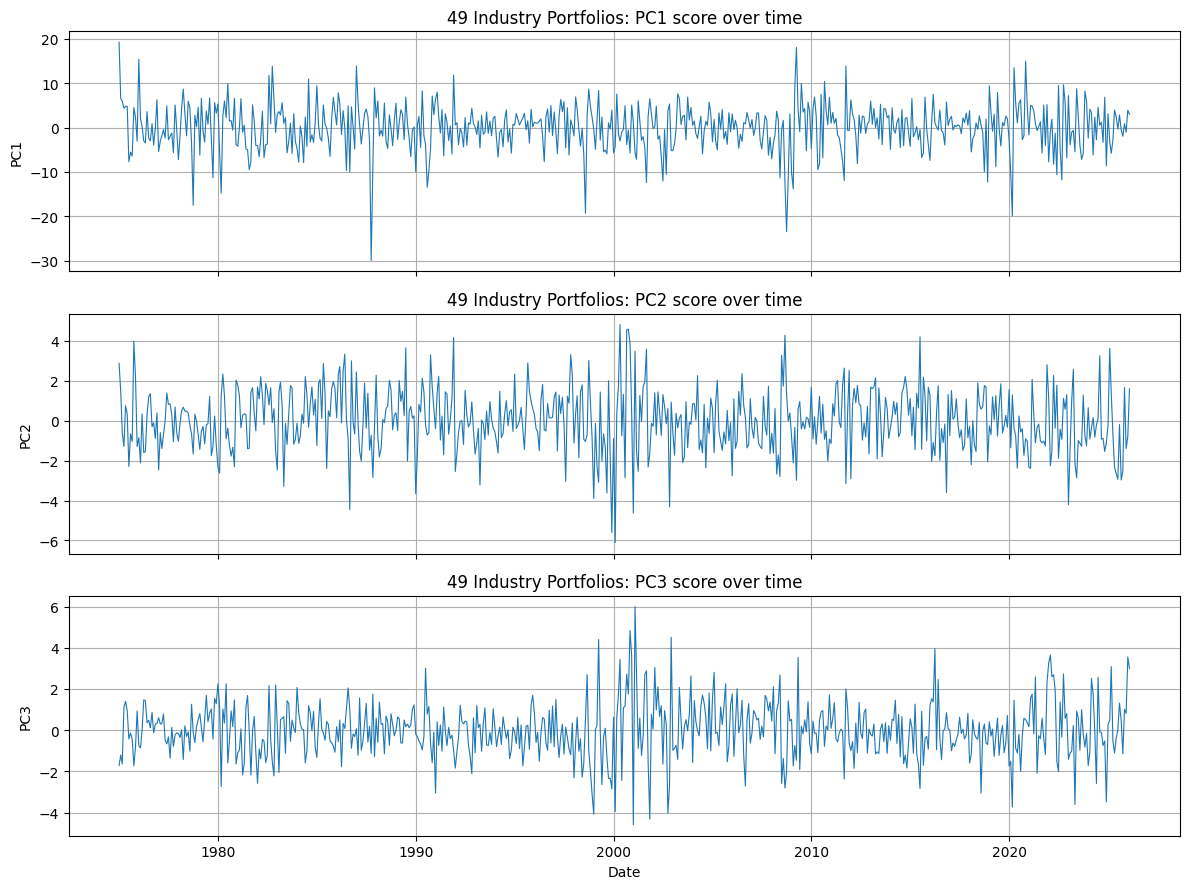

In [18]:
plot_pc_scores(intl_res, "International Indices", n_show=3)
plot_pc_scores(bm100_res, "100 Size-B/M Portfolios", n_show=3)
plot_pc_scores(ind49_res, "49 Industry Portfolios", n_show=3)

## 10×10 loading heatmaps for the 100 portfolios

For the 100 Size-B/M portfolios, loadings are especially informative because the portfolios live on a 10×10 grid:
- rows = size deciles
- columns = book-to-market deciles

This allows us to see whether a PC behaves like:
- a market factor
- a size factor
- a value factor

In [19]:
def decode_100_portfolio_label(label):
    m = re.search(r"ME(\d+)\s+BM(\d+)", label)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None


def make_10x10_grid(loadings_series):
    grid = pd.DataFrame(index=range(1, 11), columns=range(1, 11), dtype=float)

    for label, value in loadings_series.items():
        decoded = decode_100_portfolio_label(label)
        if decoded is not None:
            size, bm = decoded
            grid.loc[size, bm] = value

    return grid

In [20]:
def plot_loading_heatmaps_100(result, pcs=("PC1", "PC2", "PC3")):
    fig, axes = plt.subplots(1, len(pcs), figsize=(5 * len(pcs), 5))
    if len(pcs) == 1:
        axes = [axes]

    for ax, pc in zip(axes, pcs):
        grid = make_10x10_grid(result["loadings"][pc])
        sns.heatmap(grid, cmap="RdBu_r", center=0, ax=ax)
        ax.set_title(f"{pc} loadings")
        ax.set_xlabel("Book-to-Market decile")
        ax.set_ylabel("Size decile")

    plt.tight_layout()
    plt.show()

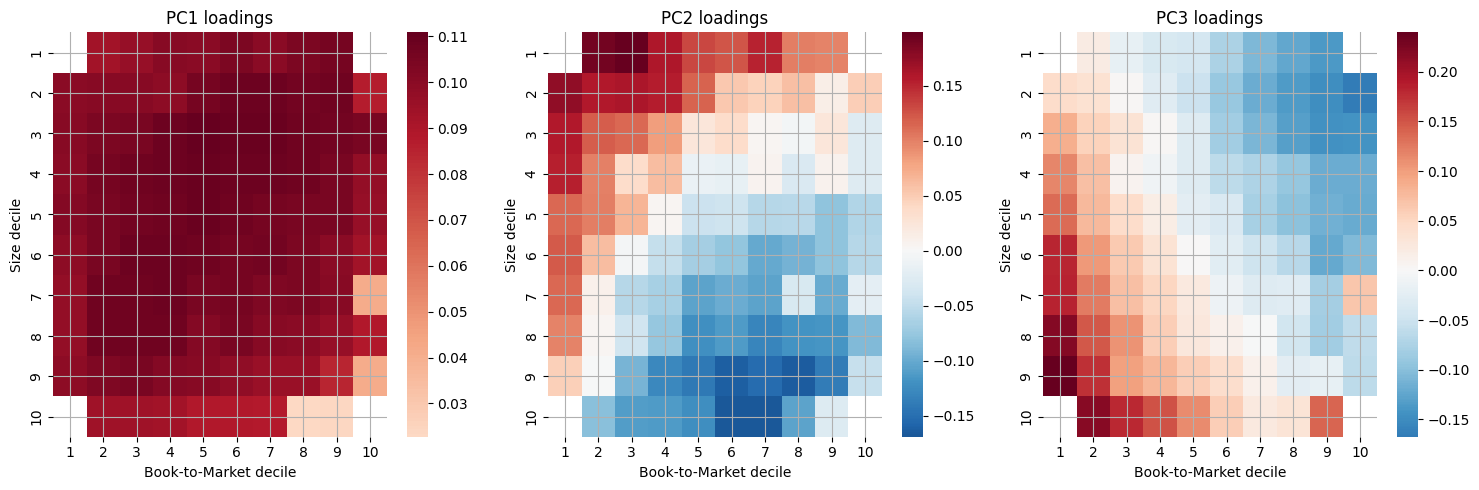

In [21]:
plot_loading_heatmaps_100(bm100_res, pcs=("PC1", "PC2", "PC3"))

### Interpretation of the 100-portfolio heatmaps

The heatmaps provide the cleanest economic interpretation of PCA:

- **PC1** is close to uniform across the grid, which means all portfolios move together.
  This is the market factor.

- **PC2** changes primarily across rows, so the main split is between small and large firms.
  This is a size-related factor.

- **PC3** changes primarily across columns, so the main split is between growth and value portfolios.
  This is a value-related factor.

A nice result here is that PCA recovers the same broad structure that Fama–French motivate economically, but it does so purely statistically.

In [22]:
def correlation_with_benchmarks(scores, benchmark):
    aligned = scores.join(benchmark, how="inner")
    return aligned.corr().loc[scores.columns, benchmark.columns]

In [23]:
ff3_ts = ff3[["Mkt-RF", "SMB", "HML"]].copy()

bm100_corrs = correlation_with_benchmarks(bm100_res["scores"], ff3_ts)
ind49_corrs = correlation_with_benchmarks(ind49_res["scores"], ff3_ts)

print("100 Size-B/M correlations")
display(bm100_corrs)

print("49 Industry correlations")
display(ind49_corrs)

100 Size-B/M correlations


,Mkt-RF,SMB,HML
PC1,0.932953,0.519856,-0.027261
PC2,-0.097096,0.685366,-0.533272
PC3,0.285967,-0.371852,-0.785031
PC4,-0.002849,0.048390,0.077735
PC5,0.038890,-0.074778,0.036372


49 Industry correlations


,Mkt-RF,SMB,HML
PC1,0.959938,0.317171,-0.055013
PC2,-0.041619,-0.386879,0.125300
PC3,-0.114581,-0.132395,0.455548
PC4,0.142368,-0.094453,-0.493259
PC5,-0.082712,0.161603,-0.226412


In [24]:
def plot_corr_heatmap(corr_df, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_df, annot=True, cmap="RdBu_r", center=0)
    plt.title(title)
    plt.show()

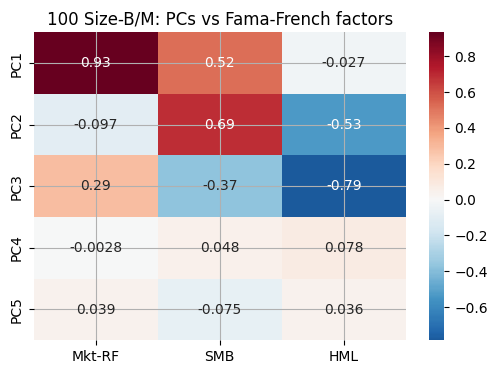

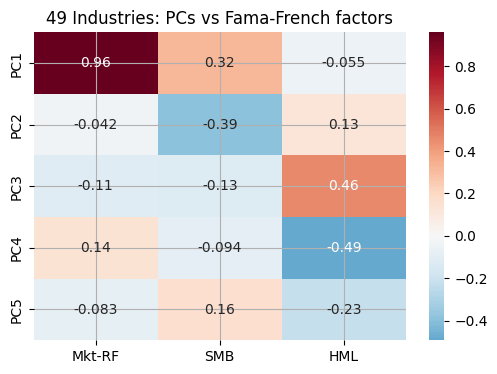

In [25]:
plot_corr_heatmap(bm100_corrs, "100 Size-B/M: PCs vs Fama-French factors")
plot_corr_heatmap(ind49_corrs, "49 Industries: PCs vs Fama-French factors")

### Why PC2 and PC3 can look “rotated”

PCA finds orthogonal directions that maximize explained variance.

The Fama–French factors, by contrast, are constructed as economically motivated long-short portfolios.

So even when PCA recovers the same underlying 2D subspace as SMB and HML, the statistical axes do not have to line up perfectly with the named economic axes.

That is why PC2 and PC3 may each load on a mixture of SMB and HML, even though together they span the same space.

In [26]:
def spanning_r2(scores_df, ff_df, K=5):
    common = scores_df.index.intersection(ff_df.index)
    X = sm.add_constant(scores_df.loc[common].iloc[:, :K])

    results = {}
    for factor in ["Mkt-RF", "SMB", "HML"]:
        y = ff_df.loc[common, factor]
        reg = sm.OLS(y, X).fit()
        results[factor] = reg.rsquared

    return pd.Series(results, name="R_squared")

In [27]:
r2_100 = spanning_r2(bm100_res["scores"], ff3_ts, K=5)
r2_ind49 = spanning_r2(ind49_res["scores"], ff3_ts, K=5)

print("Spanning R² — 100 Size/B/M")
display(r2_100)

print("Spanning R² — 49 Industries")
display(r2_ind49)

Spanning R² — 100 Size/B/M


,R_squared
Mkt-RF,0.963128
SMB,0.886184
HML,0.908762


Spanning R² — 49 Industries


,R_squared
Mkt-RF,0.963452
SMB,0.302838
HML,0.520817


### Interpretation of spanning results

The spanning regressions answer a deeper question:

> do the first five statistical PCs contain the same information as the named Fama–French factors?

For the **100 Size-B/M panel**, the answer is largely yes.
The extracted PCs span the market, size, and value factors very well.

For the **49 industry panel**, the answer is different.
The PCs still span the market well, but they do not reproduce SMB and HML effectively.
That happens because industry portfolios are not explicitly organized along size and book-to-market dimensions.

This is an important lesson:
PCA can only extract factors that are actually present in the cross-section you feed into it.

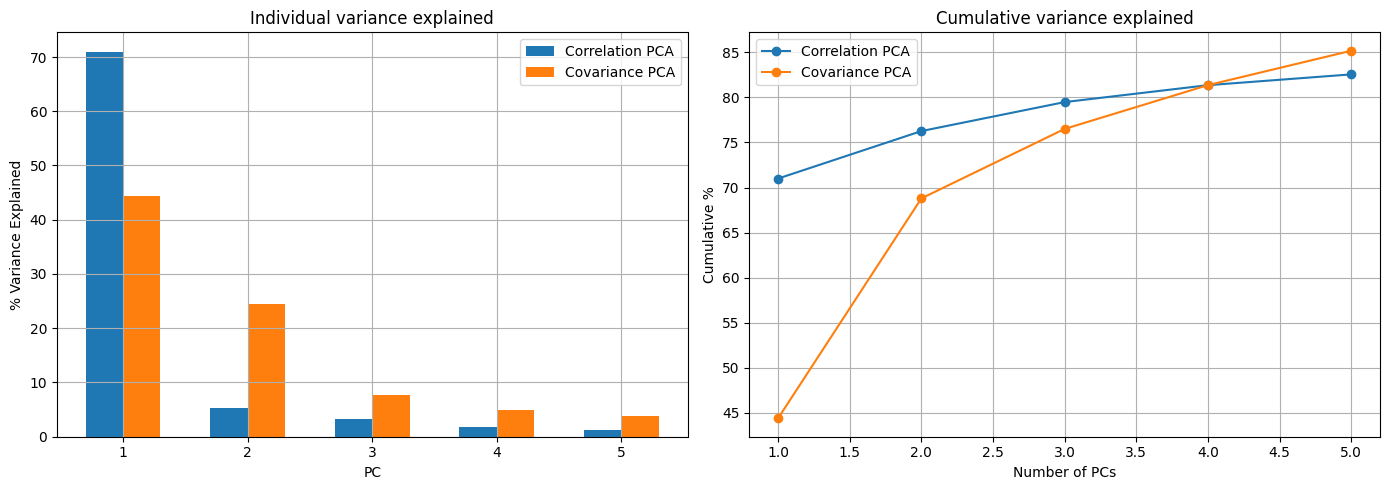

In [28]:
res_corr = run_pca(bm100_excess, n_components=5, standardize=True)
res_cov = run_pca(bm100_excess, n_components=5, standardize=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(1, 6)

axes[0].bar(x - 0.15, res_corr["explained"].values * 100, width=0.3, label="Correlation PCA")
axes[0].bar(x + 0.15, res_cov["explained"].values * 100, width=0.3, label="Covariance PCA")
axes[0].set_title("Individual variance explained")
axes[0].set_xlabel("PC")
axes[0].set_ylabel("% Variance Explained")
axes[0].legend()

axes[1].plot(x, np.cumsum(res_corr["explained"].values) * 100, marker="o", label="Correlation PCA")
axes[1].plot(x, np.cumsum(res_cov["explained"].values) * 100, marker="o", label="Covariance PCA")
axes[1].set_title("Cumulative variance explained")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative %")
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
pca_full = PCA().fit(StandardScaler().fit_transform(bm100_excess.values))
eigenvalues = pca_full.explained_variance_
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_kaiser = int(np.sum(eigenvalues > 1.0))
n_90 = int(np.searchsorted(cumvar, 0.90) + 1)
ratios = eigenvalues[1:10] / eigenvalues[:9]

print("Kaiser rule (eigenvalue > 1):", n_kaiser, "components")
print("90% cumulative variance:", n_90, "components")
print("lambda_2/lambda_1 =", round(ratios[0], 3))
print("lambda_4/lambda_3 =", round(eigenvalues[3] / eigenvalues[2], 3))
print("lambda_5/lambda_4 =", round(eigenvalues[4] / eigenvalues[3], 3))

Kaiser rule (eigenvalue > 1): 5 components
90% cumulative variance: 21 components
lambda_2/lambda_1 = 0.074
lambda_4/lambda_3 = 0.583
lambda_5/lambda_4 = 0.638


In [30]:
def rolling_pca_variance_shares(panel, window=120, n_components=5):
    dates = []
    pc1_var = []
    top3_var = []

    for end in range(window, len(panel) + 1):
        chunk = panel.iloc[end - window:end]
        Z = StandardScaler().fit_transform(chunk.values)
        pca_temp = PCA(n_components=n_components).fit(Z)

        dates.append(chunk.index[-1])
        pc1_var.append(pca_temp.explained_variance_ratio_[0] * 100)
        top3_var.append(np.sum(pca_temp.explained_variance_ratio_[:3]) * 100)

    return pd.DataFrame(
        {"PC1_share": pc1_var, "Top3_share": top3_var},
        index=pd.Index(dates, name="Date")
    )

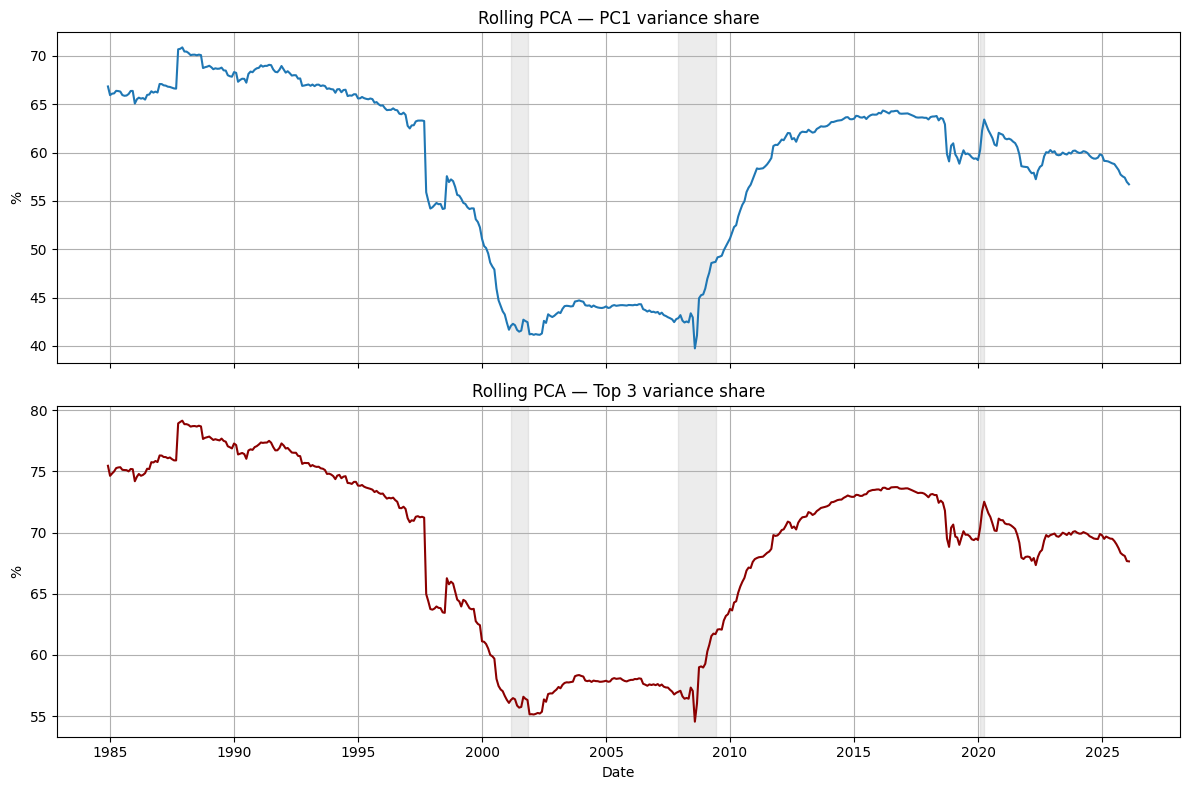

In [31]:
rolling_ind49 = rolling_pca_variance_shares(ind49_excess, window=120, n_components=5)

recessions = [
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(rolling_ind49.index, rolling_ind49["PC1_share"], label="PC1 share")
axes[0].set_title("Rolling PCA — PC1 variance share")
axes[0].set_ylabel("%")

axes[1].plot(rolling_ind49.index, rolling_ind49["Top3_share"], color="darkred", label="Top 3 share")
axes[1].set_title("Rolling PCA — Top 3 variance share")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Date")

for ax in axes:
    for start, end in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color="gray")

plt.tight_layout()
plt.show()

### Interpretation of rolling PCA

Rolling PCA shows that factor structure is not fixed over time.

During crisis periods:
- correlations across assets tend to rise
- the market factor becomes more dominant
- the share of variance explained by PC1 increases

During calmer periods:
- more cross-sectional structure becomes visible
- higher PCs matter more
- sector rotation or style-specific dynamics become more important

So the number of “relevant” factors is itself time-varying.

In [32]:
comparison = pd.DataFrame({
    "International": intl_res["explained"].iloc[:3].values * 100,
    "100 Size/B/M": bm100_res["explained"].iloc[:3].values * 100,
    "49 Industries": ind49_res["explained"].iloc[:3].values * 100,
}, index=["PC1", "PC2", "PC3"])

comparison.loc["Top 3"] = comparison.sum(axis=0)
comparison.round(1)

,International,100 Size/B/M,49 Industries
PC1,92.4,71.0,57.2
PC2,4.4,5.3,4.9
PC3,1.8,3.2,3.7
Top 3,98.6,79.5,65.8


# Conclusion

This notebook shows that PCA is a powerful statistical tool for uncovering return factor structure.

## Main findings

1. **PC1 is the market factor** across all panels.
2. The **100 Size-B/M panel** reveals additional factors closely related to **size** and **value**.
3. The **49 industry panel** reveals **sector rotation** rather than SMB/HML structure.
4. Five PCs from the 100 Size-B/M panel reproduce the Fama–French 3 factors very well in spanning regressions.
5. Factor importance changes over time: during crises, PC1 becomes more dominant.

## Economic takeaway

The factors you recover depend on the cross-section you analyze.

- Sorting by size and value highlights size/value structure.
- Sorting by industry highlights sector structure.

PCA does not impose theory.
It extracts the strongest common variation that is actually present in the data.

In [33]:
print("Notebook ran successfully.")
print("International panel shape:", intl_panel.shape)
print("100 Size-B/M panel shape:", bm100_excess.shape)
print("49 Industry panel shape:", ind49_excess.shape)
print()
print("100 Size-B/M explained variance:")
print((bm100_res["explained"] * 100).round(2))
print()
print("100 Size-B/M spanning R²:")
print(r2_100.round(3))

Notebook ran successfully.
International panel shape: (612, 10)
100 Size-B/M panel shape: (614, 100)
49 Industry panel shape: (614, 49)

100 Size-B/M explained variance:
PC1    71.00
PC2     5.27
PC3     3.22
PC4     1.88
PC5     1.20
Name: ExplainedVarianceRatio, dtype: float64

100 Size-B/M spanning R²:
Mkt-RF    0.963
SMB       0.886
HML       0.909
Name: R_squared, dtype: float64
